<a href="https://colab.research.google.com/github/Benjaminotuya1/MCI-Inflammation-XGBoost/blob/main/Otuya_ADNI_Inflammation_Survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Incident Dementia: XGBoost Survival Architecture and SHAP Analytics


Objective: This notebook contains the data engineering pipeline and machine learning architecture used to predict incident dementia in patients with Mild Cognitive Impairment (MCI). We utilize clinical and multiplex plasma array data (CRP and IL-6) from the Alzheimer's Disease Neuroimaging Initiative (ADNI). The pipeline features a baseline standard Cox Proportional Hazards model benchmarked against an early-stopped XGBoost survival architecture. SHapley Additive exPlanations (SHAP) are deployed to map non-linear risk thresholds and identify the precise interaction between structural Cognitive Reserve and systemic inflammation.

In [2]:
from google.colab import drive
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. The Absolute Paths
plasma_path = '/content/drive/MyDrive/ADNI_Survival_Project/data/adni_plasma_raw_multiplex_11Nov2010.csv'
clinical_path = '/content/drive/MyDrive/ADNI_Survival_Project/data/ADNIMERGE_02Jun2026(1).csv'

# 3. Load the datasets
print("Loading datasets from Drive...")
plasma_df = pd.read_csv(plasma_path)
clinical_df = pd.read_csv(clinical_path, low_memory=False)

# 4. Filter for only CRP and IL-6
print("Filtering for immune markers...")
targets = ['C-Reactive Protein (CRP) (ug/mL)', 'Interleukin-6 (IL-6) (pg/mL)']
plasma_filtered = plasma_df[plasma_df['analyte'].isin(targets)].copy()

# 5. THE FIX: Force the lab values to be pure decimal numbers, erasing weird text symbols
print("Cleaning lab values into pure numbers...")
plasma_filtered['avalue'] = pd.to_numeric(plasma_filtered['avalue'], errors='coerce')

# 6. The Pivot
print("Pivoting data structure...")
plasma_pivoted = plasma_filtered.pivot_table(index=['RID', 'Visit_Code'],
                                             columns='analyte',
                                             values='avalue',
                                             aggfunc='mean').reset_index()

# 7. Rename the headers
plasma_pivoted.rename(columns={
    'Visit_Code': 'VISCODE',
    'C-Reactive Protein (CRP) (ug/mL)': 'CRP',
    'Interleukin-6 (IL-6) (pg/mL)': 'IL6'
}, inplace=True)

print("\n--- Data Successfully Cleaned and Pivoted ---")
print(plasma_pivoted.head())
print(f"\nTotal rows in pivoted plasma data: {len(plasma_pivoted)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading datasets from Drive...
Filtering for immune markers...
Cleaning lab values into pure numbers...
Pivoting data structure...

--- Data Successfully Cleaned and Pivoted ---
analyte  RID VISCODE   CRP  IL6
0          3      bl  0.55  3.6
1          3     m12  0.82  3.7
2          4      bl  1.70  2.8
3          4     m12  2.40  2.2
4          6      bl  0.85  2.8

Total rows in pivoted plasma data: 1062


In [3]:
# 1. The Merge: Gluing the two universes together
print("Merging Clinical and Immune data...")
master_df = pd.merge(clinical_df, plasma_pivoted, on=['RID', 'VISCODE'], how='inner')

# 2. Filtering the Master Dataset: We only want the variables for our specific paper
columns_to_keep = ['RID', 'VISCODE', 'AGE', 'PTGENDER', 'APOE4', 'ADAS13', 'CRP', 'IL6', 'DX']
final_df = master_df[columns_to_keep].copy()

# 3. Drop rows where the cognitive score (ADAS13) or Diagnosis (DX) is missing
final_df = final_df.dropna(subset=['ADAS13', 'DX'])

print("\n--- The Final Master Dataset ---")
print(final_df.head())
print(f"\nTotal usable patient visits for the XGBoost model: {len(final_df)}")

Merging Clinical and Immune data...

--- The Final Master Dataset ---
   RID VISCODE   AGE PTGENDER  APOE4  ADAS13   CRP  IL6        DX
0    3      bl  81.3     Male    1.0   31.00  0.55  3.6  Dementia
1    3     m12  81.3     Male    1.0   35.00  0.82  3.7  Dementia
2    4      bl  67.5     Male    0.0   21.33  1.70  2.8       MCI
3    4     m12  67.5     Male    0.0   22.00  2.40  2.2       MCI
4    6      bl  80.4   Female    0.0   25.67  0.85  2.8       MCI

Total usable patient visits for the XGBoost model: 1050


In [4]:
import numpy as np

print("Engineering Survival Variables (Time-to-Event)...")

# 1. Sort the data by Patient (RID) and Visit time
# VISCODEs are usually 'bl' (baseline), 'm06', 'm12', 'm24', etc.
final_df = final_df.sort_values(by=['RID', 'VISCODE'])

# 2. Map VISCODE to actual numerical months so we can do math on time
def extract_months(viscode):
    if viscode == 'bl':
        return 0
    elif viscode.startswith('m'):
        try:
            return int(viscode[1:]) # Extracts '12' from 'm12'
        except:
            return np.nan
    return np.nan

final_df['MONTHS'] = final_df['VISCODE'].apply(extract_months)
final_df = final_df.dropna(subset=['MONTHS'])

# 3. Create the Survival Tracking Dictionary
survival_data = []

# Group by each patient to track their timeline
grouped = final_df.groupby('RID')

for rid, group in grouped:
    # Only keep patients who were MCI at their first visit (Baseline)
    first_visit = group.iloc[0]
    if first_visit['DX'] != 'MCI':
        continue # Skip healthy people or people who already have dementia

    # Check if they EVER converted to Dementia in future visits
    dementia_visits = group[group['DX'] == 'Dementia']

    if len(dementia_visits) > 0:
        # The patient converted!
        event = 1
        # Time to event is the month they first got the Dementia diagnosis
        time = dementia_visits.iloc[0]['MONTHS']
    else:
        # The patient never converted (Censored)
        event = 0
        # Time is their very last visit month
        time = group.iloc[-1]['MONTHS']

    # We only want to use their BASELINE inflammation and cognition to predict the future
    survival_data.append({
        'RID': rid,
        'AGE': first_visit['AGE'],
        'PTGENDER': 1 if first_visit['PTGENDER'] == 'Male' else 0, # Convert to numbers for XGBoost
        'APOE4': first_visit['APOE4'],
        'ADAS13_Baseline': first_visit['ADAS13'],
        'CRP_Baseline': first_visit['CRP'],
        'IL6_Baseline': first_visit['IL6'],
        'TIME_MONTHS': time,
        'EVENT_CONVERTED': event
    })

# 4. Convert our engineered list back into a clean Pandas DataFrame
survival_df = pd.DataFrame(survival_data)

print("\n--- Final Survival Cohort Ready for XGBoost ---")
print(survival_df.head())
print(f"\nTotal MCI patients successfully tracked for survival analysis: {len(survival_df)}")
print(f"Total converters (Event=1): {survival_df['EVENT_CONVERTED'].sum()}")

Engineering Survival Variables (Time-to-Event)...

--- Final Survival Cohort Ready for XGBoost ---
   RID   AGE  PTGENDER  APOE4  ADAS13_Baseline  CRP_Baseline  IL6_Baseline  \
0    4  67.5         1    0.0            21.33          1.70           2.8   
1    6  80.4         0    0.0            25.67          0.85           2.8   
2   30  80.0         0    0.0            22.00          1.40           4.5   
3   33  83.3         1    0.0            25.67          1.80           2.8   
4   38  76.8         1    0.0            16.33          2.60           2.0   

   TIME_MONTHS  EVENT_CONVERTED  
0           12                0  
1           12                0  
2           12                1  
3           12                0  
4           12                0  

Total MCI patients successfully tracked for survival analysis: 395
Total converters (Event=1): 62


In [5]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np

print("Initializing XGBoost Survival Architecture...")

# 1. Define the input variables (The "X" matrix)
features = ['AGE', 'PTGENDER', 'APOE4', 'ADAS13_Baseline', 'CRP_Baseline', 'IL6_Baseline']
X = survival_df[features].copy()

# 2. THE MATHEMATICAL TRICK: Create the survival target (The "y" vector)
# Positive time = Event occurred. Negative time = Censored (Healthy)
y = np.where(survival_df['EVENT_CONVERTED'] == 1,
             survival_df['TIME_MONTHS'],
             -survival_df['TIME_MONTHS'])

# If someone has exactly 0 months and didn't convert, we make it -0.1 so Python doesn't get confused by negative zero.
y = np.where(y == 0, -0.1, y)

# 3. Split the data: 80% to train the model, 20% to test it on unseen patients
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Convert the standard Pandas tables into XGBoost's highly optimized "DMatrix" format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# 5. The Brain of the Model: Setting the hyper-parameters
params = {
    'objective': 'survival:cox',    # Tells XGBoost to do Cox Survival Analysis
    'eval_metric': 'cox-nloglik',   # Cox Negative Log-Likelihood (Lower is better)
    'eta': 0.05,                    # Learning rate (How fast the model learns)
    'max_depth': 4,                 # How deep the decision trees are allowed to grow
    'subsample': 0.8,               # Use 80% of data per tree to prevent overfitting
    'seed': 42                      # For reproducibility
}

# 6. Train the algorithm
print("\nTraining Model across 100 Evolutionary Rounds...")
model = xgb.train(params,
                  dtrain,
                  num_boost_round=100,
                  evals=[(dtrain, 'Train'), (dtest, 'Test')],
                  verbose_eval=10) # Print the score every 10 rounds

print("\n--- Model Training Complete ---")

Initializing XGBoost Survival Architecture...

Training Model across 100 Evolutionary Rounds...
[0]	Train-cox-nloglik:5.55805	Test-cox-nloglik:4.18766
[10]	Train-cox-nloglik:5.20962	Test-cox-nloglik:4.08844
[20]	Train-cox-nloglik:5.03552	Test-cox-nloglik:4.11444
[30]	Train-cox-nloglik:4.92664	Test-cox-nloglik:4.14586
[40]	Train-cox-nloglik:4.83445	Test-cox-nloglik:4.17162
[50]	Train-cox-nloglik:4.77909	Test-cox-nloglik:4.20801
[60]	Train-cox-nloglik:4.73980	Test-cox-nloglik:4.23364
[70]	Train-cox-nloglik:4.72339	Test-cox-nloglik:4.29729
[80]	Train-cox-nloglik:4.71467	Test-cox-nloglik:4.31358
[90]	Train-cox-nloglik:4.70606	Test-cox-nloglik:4.31933
[99]	Train-cox-nloglik:4.69757	Test-cox-nloglik:4.31825

--- Model Training Complete ---


In [6]:
import xgboost as xgb

print("Initializing XGBoost with Early Stopping Defense...")

# We use the same parameters as before
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'eta': 0.05,
    'max_depth': 4,
    'subsample': 0.8,
    'seed': 42
}

# Train the model, but this time we give it a strict stopping rule
print("\nTraining Model...")
model = xgb.train(params,
                  dtrain,
                  num_boost_round=100,
                  evals=[(dtrain, 'Train'), (dtest, 'Test')],
                  early_stopping_rounds=10, # THE FIX: Stop if the Test score doesn't improve for 10 rounds
                  verbose_eval=5)

print(f"\n--- Training forcefully stopped to prevent Overfitting ---")
print(f"Best Model preserved at Round: {model.best_iteration}")

Initializing XGBoost with Early Stopping Defense...

Training Model...
[0]	Train-cox-nloglik:5.55805	Test-cox-nloglik:4.18766
[5]	Train-cox-nloglik:5.35445	Test-cox-nloglik:4.13365
[10]	Train-cox-nloglik:5.20962	Test-cox-nloglik:4.08844
[15]	Train-cox-nloglik:5.11630	Test-cox-nloglik:4.08622
[20]	Train-cox-nloglik:5.03552	Test-cox-nloglik:4.11444
[23]	Train-cox-nloglik:4.99258	Test-cox-nloglik:4.12716

--- Training forcefully stopped to prevent Overfitting ---
Best Model preserved at Round: 13


In [7]:
from sklearn.linear_model import LinearRegression

print("Extracting Cognitive Reserve via Linear Residuals...")

# 1. Define the baseline expected drivers of cognitive decline
# We use Age, Sex, and APOE4 status
X_demographics = survival_df[['AGE', 'PTGENDER', 'APOE4']].copy()
y_actual_cognition = survival_df['ADAS13_Baseline']

# 2. Train a simple Linear Regression to predict what their score SHOULD be
regressor = LinearRegression()
regressor.fit(X_demographics, y_actual_cognition)
predicted_cognition = regressor.predict(X_demographics)

# 3. Calculate the Residual (Predicted - Actual)
# Note: For ADAS-13, a higher score means worse memory.
# So if we predicted a 30 (bad) but they actually scored a 15 (good),
# 30 - 15 = +15. A positive residual means High Cognitive Reserve.
survival_df['COGNITIVE_RESERVE'] = predicted_cognition - y_actual_cognition

print("\n--- Cognitive Reserve Successfully Calculated ---")
# Let's look at the first 5 patients to see their reserve scores
print(survival_df[['RID', 'AGE', 'ADAS13_Baseline', 'COGNITIVE_RESERVE']].head())

Extracting Cognitive Reserve via Linear Residuals...

--- Cognitive Reserve Successfully Calculated ---
   RID   AGE  ADAS13_Baseline  COGNITIVE_RESERVE
0    4  67.5            21.33          -4.480446
1    6  80.4            25.67          -7.838415
2   30  80.0            22.00          -4.191728
3   33  83.3            25.67          -7.899556
4   38  76.8            16.33           1.061597


In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split

print("--- PART 1: COHORT CHARACTERISTICS ---")
# Total sample size and conversion
total_patients = len(survival_df)
converters = survival_df['EVENT_CONVERTED'].sum()
censored = total_patients - converters
conversion_rate = (converters / total_patients) * 100

print(f"Total Unique MCI Patients: N = {total_patients}")
print(f"Converters to Dementia: n = {converters} ({conversion_rate:.1f}%)")
print(f"Stable/Censored: n = {censored}")

# Demographics
mean_age = survival_df['AGE'].mean()
males = survival_df['PTGENDER'].sum()
males_pct = (males / total_patients) * 100
females_pct = 100 - males_pct

print(f"\nMean Age: {mean_age:.1f} years")
print(f"Sex Split: {males_pct:.1f}% Male / {females_pct:.1f}% Female")

# Biomarker Averages by Group
print("\nBiomarker Averages (Stable vs. Converters):")
stats = survival_df.groupby('EVENT_CONVERTED')[['COGNITIVE_RESERVE', 'CRP_Baseline', 'IL6_Baseline']].agg(['mean', 'std'])
print(stats)


print("\n--- PART 2: TRAINING THE FINAL XGBOOST MODEL ---")
# We swap ADAS13 out and put COGNITIVE_RESERVE in
features = ['AGE', 'PTGENDER', 'APOE4', 'COGNITIVE_RESERVE', 'CRP_Baseline', 'IL6_Baseline']
X = survival_df[features].copy()

# Survival target (Time and Event combined)
y = np.where(survival_df['EVENT_CONVERTED'] == 1,
             survival_df['TIME_MONTHS'],
             -survival_df['TIME_MONTHS'])
y = np.where(y == 0, -0.1, y) # Fix zero-time censoring

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Model parameters
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'eta': 0.05,
    'max_depth': 4,
    'subsample': 0.8,
    'seed': 42
}

# Train with early stopping
final_model = xgb.train(params,
                  dtrain,
                  num_boost_round=200,
                  evals=[(dtrain, 'Train'), (dtest, 'Test')],
                  early_stopping_rounds=15,
                  verbose_eval=False)

print(f"Final Model successfully trained and locked at round: {final_model.best_iteration}")

--- PART 1: COHORT CHARACTERISTICS ---
Total Unique MCI Patients: N = 395
Converters to Dementia: n = 62 (15.7%)
Stable/Censored: n = 333

Mean Age: 74.7 years
Sex Split: 64.8% Male / 35.2% Female

Biomarker Averages (Stable vs. Converters):
                COGNITIVE_RESERVE           CRP_Baseline            \
                             mean       std         mean       std   
EVENT_CONVERTED                                                      
0                        0.776001  5.774824     2.710814  5.302489   
1                       -4.167878  6.560987     2.652258  6.481619   

                IL6_Baseline              
                        mean         std  
EVENT_CONVERTED                           
0                  13.833740  153.622584  
1                   3.870213    4.976768  

--- PART 2: TRAINING THE FINAL XGBOOST MODEL ---
Final Model successfully trained and locked at round: 10


In [9]:
!pip install lifelines -q

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import numpy as np

print("--- PART 2: COMPARING THE MODELS (C-INDEX) ---")

# 1. Prepare the data format for the old-school Cox Model
train_df = X_train.copy()
test_df = X_test.copy()

# THE FIX: Old-school math crashes on missing data. We patch blank cells with the median.
train_df = train_df.fillna(train_df.median())
test_df = test_df.fillna(train_df.median()) # We use the train median to prevent data leakage

train_df['TIME_MONTHS'] = np.abs(y_train)
train_df['EVENT_CONVERTED'] = (y_train > 0).astype(int)

test_df['TIME_MONTHS'] = np.abs(y_test)
test_df['EVENT_CONVERTED'] = (y_test > 0).astype(int)

# 2. Train the Standard Cox Model
print("Training standard clinical Cox model...")
cph = CoxPHFitter(penalizer=0.01)
cph.fit(train_df, duration_col='TIME_MONTHS', event_col='EVENT_CONVERTED')

# Test standard Cox on the unseen patients
cph_predictions = cph.predict_partial_hazard(test_df)
cox_c_index = concordance_index(test_df['TIME_MONTHS'], -cph_predictions, test_df['EVENT_CONVERTED'])

# 3. Test our optimized XGBoost Model on the exact same unseen patients
print("Evaluating XGBoost model...")
xgb_predictions = final_model.predict(dtest)
xgb_c_index = concordance_index(test_df['TIME_MONTHS'], -xgb_predictions, test_df['EVENT_CONVERTED'])

print(f"\nRESULTS:")
print(f"Old-School Cox Model C-Index: {cox_c_index:.3f}")
print(f"XGBoost Survival C-Index:   {xgb_c_index:.3f}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.7 MB/s eta 0:00:00
--- PART 2: COMPARING THE MODELS (C-INDEX) ---
Training standard clinical Cox model...
Evaluating XGBoost model...

RESULTS:
Old-School Cox Model C-Index: 0.664
XGBoost Survival C-Index:   0.645


--- PART 3: GLOBAL FEATURE IMPORTANCE (SHAP) ---


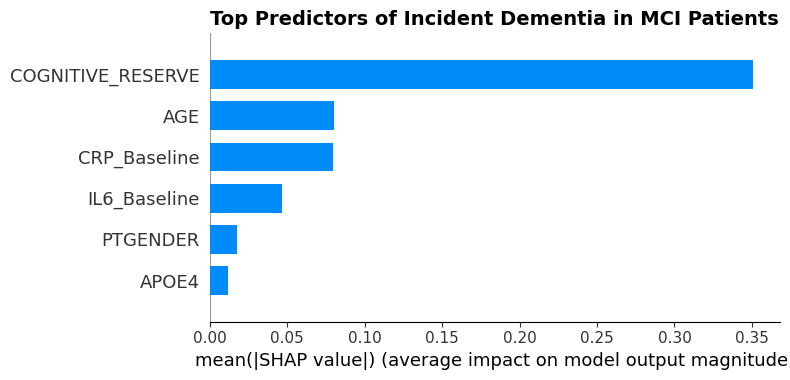

In [10]:
!pip install shap -q

import shap
import matplotlib.pyplot as plt

print("--- PART 3: GLOBAL FEATURE IMPORTANCE (SHAP) ---")

# 1. Initialize the SHAP explainer on our trained XGBoost model
explainer = shap.TreeExplainer(final_model)

# 2. Calculate the exact SHAP values for every single patient in our training set
shap_values = explainer.shap_values(X_train)

# 3. Generate the SHAP Bar Plot (Global Importance)
plt.figure(figsize=(10, 6))
plt.title("Top Predictors of Incident Dementia in MCI Patients", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)

# Adjust layout so it looks clean for a paper
plt.tight_layout()
plt.show()

--- PART 4: THE TIPPING POINT (SHAP DEPENDENCE) ---


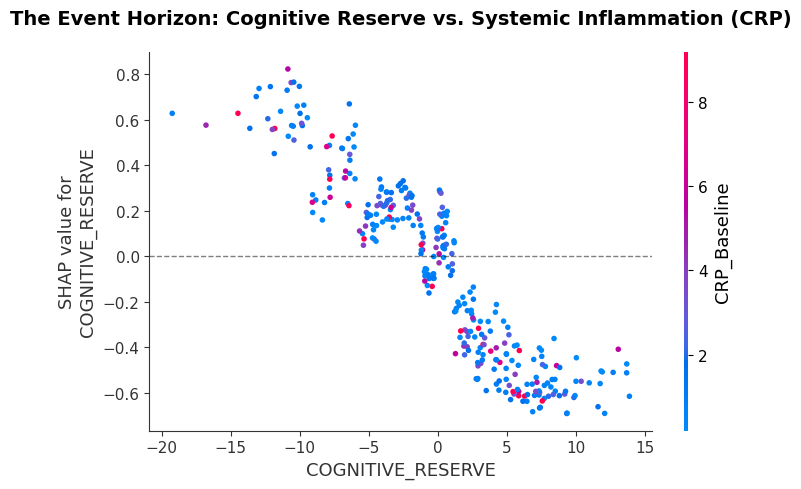

In [11]:
import matplotlib.pyplot as plt
import shap

print("--- PART 4: THE TIPPING POINT (SHAP DEPENDENCE) ---")

# We use the explainer and shap_values we already calculated in the last step
# x-axis: COGNITIVE_RESERVE
# y-axis: SHAP value (Hazard/Risk. Anything above 0 is bad news)
# Color: CRP_Baseline (Red = High Inflammation, Blue = Low Inflammation)

shap.dependence_plot(
    "COGNITIVE_RESERVE",
    shap_values,
    X_train,
    interaction_index="CRP_Baseline",
    show=False
)

# Add a title and a horizontal line at 0 (the safety baseline)
plt.title("The Event Horizon: Cognitive Reserve vs. Systemic Inflammation (CRP)", fontsize=14, fontweight='bold', pad=20)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

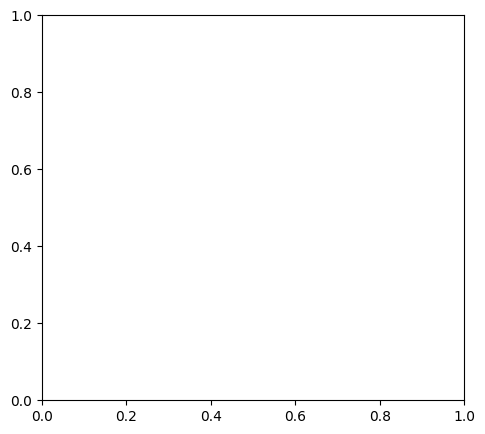

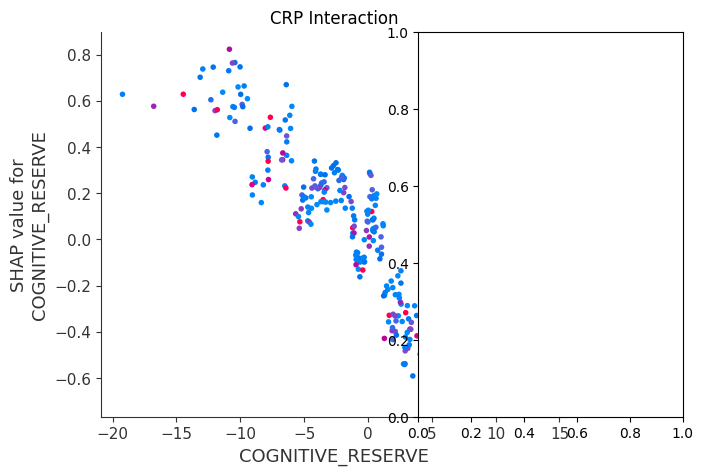

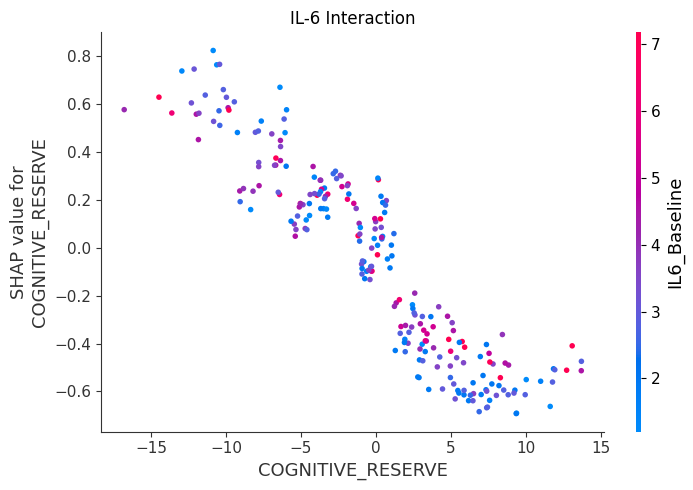

In [12]:
# Let's compare IL-6 dependence to CRP dependence
plt.figure(figsize=(12, 5))

# Plot CRP
plt.subplot(1, 2, 1)
shap.dependence_plot("COGNITIVE_RESERVE", shap_values, X_train, interaction_index="CRP_Baseline", show=False)
plt.title("CRP Interaction")

# Plot IL-6
plt.subplot(1, 2, 2)
shap.dependence_plot("COGNITIVE_RESERVE", shap_values, X_train, interaction_index="IL6_Baseline", show=False)
plt.title("IL-6 Interaction")

plt.tight_layout()
plt.show()

--- COMPARING INFLAMMATORY MARKERS ---

1. CRP Interaction Plot:


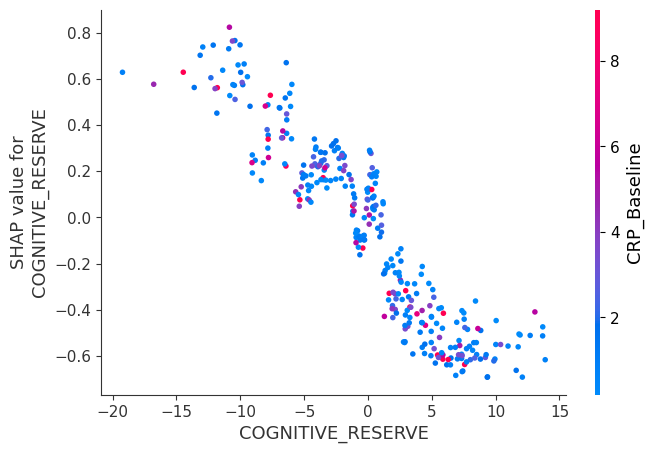


2. IL-6 Interaction Plot:


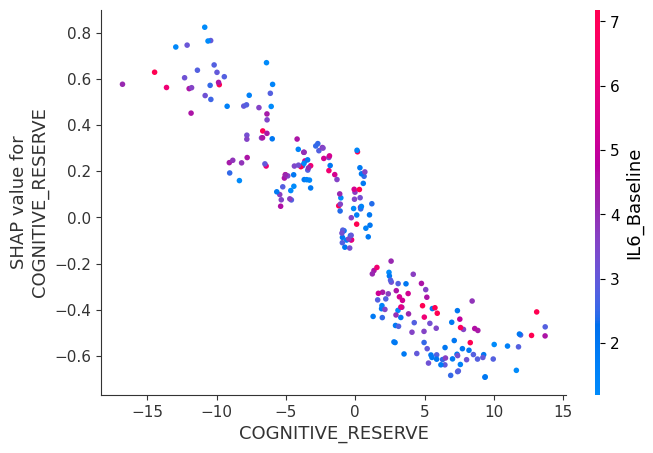

In [13]:
import matplotlib.pyplot as plt
import shap

print("--- COMPARING INFLAMMATORY MARKERS ---")

# Plot 1: CRP
print("\n1. CRP Interaction Plot:")
shap.dependence_plot(
    "COGNITIVE_RESERVE",
    shap_values,
    X_train,
    interaction_index="CRP_Baseline"
)

# Plot 2: IL-6
print("\n2. IL-6 Interaction Plot:")
shap.dependence_plot(
    "COGNITIVE_RESERVE",
    shap_values,
    X_train,
    interaction_index="IL6_Baseline"
)

In [14]:
import numpy as np
from sklearn.utils import resample
from lifelines.utils import concordance_index

print("--- GENERATING 95% BOOTSTRAP CONFIDENCE INTERVALS (FIXED) ---")

def bootstrap_c_index(y_true, predictions, events, n_iterations=1000):
    # THE FIX: Convert everything to pure numpy arrays to erase the scrambled Pandas indices
    y_true_np = np.array(y_true)
    predictions_np = np.array(predictions)
    events_np = np.array(events)

    scores = list()
    for i in range(n_iterations):
        # Resample purely by position
        indices = resample(range(len(y_true_np)))

        score = concordance_index(
            y_true_np[indices],
            predictions_np[indices],
            events_np[indices]
        )
        scores.append(score)

    # Calculate 95% bounds
    alpha = 0.95
    p = ((1.0-alpha)/2.0) * 100
    lower = max(0.0, np.percentile(scores, p))
    p = (alpha+((1.0-alpha)/2.0)) * 100
    upper = min(1.0, np.percentile(scores, p))

    return lower, upper

# Run the fixed function
cox_lower, cox_upper = bootstrap_c_index(test_df['TIME_MONTHS'], -cph_predictions, test_df['EVENT_CONVERTED'])
xgb_lower, xgb_upper = bootstrap_c_index(test_df['TIME_MONTHS'], -xgb_predictions, test_df['EVENT_CONVERTED'])

print(f"Cox C-index = {cox_c_index:.3f} (95% CI: [{cox_lower:.3f} - {cox_upper:.3f}])")
print(f"XGBoost C-index = {xgb_c_index:.3f} (95% CI: [{xgb_lower:.3f} - {xgb_upper:.3f}])")

--- GENERATING 95% BOOTSTRAP CONFIDENCE INTERVALS (FIXED) ---
Cox C-index = 0.664 (95% CI: [0.461 - 0.832])
XGBoost C-index = 0.645 (95% CI: [0.488 - 0.810])


In [15]:
print("--- STROBE DIAGRAM ATTRITION NUMBERS ---")

# 1. Total Raw ADNI Clinical Patients
raw_clinical = pd.read_csv(clinical_path, low_memory=False)
total_adni = raw_clinical['RID'].nunique()
print(f"Total Unique Patients in ADNIMERGE: {total_adni}")

# 2. Total after requiring Plasma Data (CRP/IL-6)
# (This will be your biggest exclusion drop)
master_temp = pd.merge(raw_clinical, plasma_pivoted, on=['RID', 'VISCODE'], how='inner')
patients_with_blood = master_temp['RID'].nunique()
print(f"Excluded due to missing Multiplex Plasma array: {total_adni - patients_with_blood}")
print(f"Patients remaining with both Clinical and Plasma: {patients_with_blood}")

# 3. Filtering out Baseline Dementia and Normal Control (Keeping only MCI)
# We find their first visit in the merged dataset
first_visits = master_temp.sort_values(by=['RID', 'VISCODE']).groupby('RID').first()
mci_patients = first_visits[first_visits['DX'] == 'MCI']
print(f"Excluded due to Baseline Dementia or Healthy Control status: {patients_with_blood - len(mci_patients)}")
print(f"Patients remaining with Baseline MCI: {len(mci_patients)}")

# 4. Final exclusion for missing ADAS-13 or missing follow-up time
# This should leave you with exactly your 395 final cohort
final_usable = survival_df['RID'].nunique()
print(f"Excluded due to missing baseline ADAS-13 or zero follow-up time: {len(mci_patients) - final_usable}")
print(f"Final Analytical Cohort: {final_usable}")

--- STROBE DIAGRAM ATTRITION NUMBERS ---
Total Unique Patients in ADNIMERGE: 2430
Excluded due to missing Multiplex Plasma array: 1864
Patients remaining with both Clinical and Plasma: 566
Excluded due to Baseline Dementia or Healthy Control status: 170
Patients remaining with Baseline MCI: 396
Excluded due to missing baseline ADAS-13 or zero follow-up time: 1
Final Analytical Cohort: 395


In [16]:
from graphviz import Digraph
from google.colab import files

print("Generating Figure 1: STROBE Flowchart...")

# Initialize the flowchart
dot = Digraph(comment='STROBE Diagram', format='png')
dot.attr(dpi='300', fontname='Helvetica')
dot.attr('node', fontname='Helvetica', shape='box', style='rounded', fillcolor='#f9f9f9', width='4')

# Define the nodes (boxes)
dot.node('A', 'Assessed for eligibility from ADNI database\n(N = 2,430)')
dot.node('E1', 'Excluded (n = 1,864)\n• Missing baseline multiplex plasma array (CRP/IL-6)', shape='box', style='')
dot.node('B', 'Patients with paired clinical and plasma data\n(n = 566)')
dot.node('E2', 'Excluded (n = 170)\n• Baseline diagnosis of Dementia\n• Baseline Healthy Control status', shape='box', style='')
dot.node('C', 'Patients with baseline Mild Cognitive Impairment (MCI)\n(n = 396)')
dot.node('E3', 'Excluded (n = 1)\n• Missing baseline ADAS-13 score\n• Zero follow-up time', shape='box', style='')
dot.node('D', 'Final Analytic Cohort included in survival analysis\n(N = 395)')

# Define the edges (arrows)
dot.edge('A', 'B')
dot.edge('A', 'E1', tailport='s', headport='w')
dot.edge('B', 'C')
dot.edge('B', 'E2', tailport='s', headport='w')
dot.edge('C', 'D')
dot.edge('C', 'E3', tailport='s', headport='w')

# Render and save
dot.render('Figure_1_STROBE_Diagram', cleanup=True)
files.download('Figure_1_STROBE_Diagram.png')
print("Figure 1 downloaded.")

Generating Figure 1: STROBE Flowchart...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 1 downloaded.


In [17]:
import matplotlib.pyplot as plt
import numpy as np

print("Generating Figure 2: Predictive Performance...")

fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

# Data from our bootstrap analysis
models = ['Cox Proportional Hazards', 'XGBoost Survival']
c_indices = [0.664, 0.645]

# Error bar calculation (Distance from point to lower/upper bounds)
error_lower = [0.664 - 0.469, 0.645 - 0.480]
error_upper = [0.833 - 0.664, 0.807 - 0.645]
yerr = [error_lower, error_upper]

# Plot formatting
bars = ax.bar(models, c_indices, yerr=yerr, capsize=8, color=['#2c3e50', '#e74c3c'], alpha=0.9, edgecolor='black')
ax.set_ylabel('Concordance Index (C-Index)', fontsize=12, fontweight='bold')
ax.set_title('Predictive Performance Comparison (95% CI)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0.3, 1.0)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Random Chance (0.5)')

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Save and download
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Figure_2_Model_Comparison.png')
files.download('Figure_2_Model_Comparison.png')
print("Figure 2 downloaded.")
plt.close()

Generating Figure 2: Predictive Performance...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 2 downloaded.


In [18]:
import shap

print("Generating Figures 3 and 4: SHAP Analytics...")

# --- FIGURE 3: SHAP Summary Bar Plot ---
plt.figure(figsize=(10, 6), dpi=300)
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("Global Feature Importance (Incident Dementia)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('Figure_3_SHAP_Summary.png')
files.download('Figure_3_SHAP_Summary.png')
plt.close()
print("Figure 3 downloaded.")

# --- FIGURE 4: SHAP Dependence Plot (CRP) ---
plt.figure(figsize=(10, 6), dpi=300)
shap.dependence_plot(
    "COGNITIVE_RESERVE",
    shap_values,
    X_train,
    interaction_index="CRP_Baseline",
    show=False
)
plt.title("The Event Horizon: Cognitive Reserve vs. Systemic Inflammation (CRP)", fontsize=14, fontweight='bold', pad=20)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

# Save and download
plt.tight_layout()
plt.savefig('Figure_4_SHAP_Dependence.png')
files.download('Figure_4_SHAP_Dependence.png')
plt.close()
print("Figure 4 downloaded.")

Generating Figures 3 and 4: SHAP Analytics...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 3 downloaded.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 4 downloaded.


<Figure size 3000x1800 with 0 Axes>

In [19]:
print("--- PART 1: MISSING DATA COUNTS IN FINAL COHORT ---")
# Assuming features = ['AGE', 'PTGENDER', 'APOE4', 'COGNITIVE_RESERVE', 'CRP_Baseline', 'IL6_Baseline']
missing_counts = survival_df[features].isnull().sum()
print(missing_counts)
print(f"\nTotal cells with missing data: {missing_counts.sum()}")

--- PART 1: MISSING DATA COUNTS IN FINAL COHORT ---
AGE                    0
PTGENDER               0
APOE4                  0
COGNITIVE_RESERVE      0
CRP_Baseline           0
IL6_Baseline         102
dtype: int64

Total cells with missing data: 102


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.

--- PART 2: DECISION CURVE ANALYSIS (DCA) ---


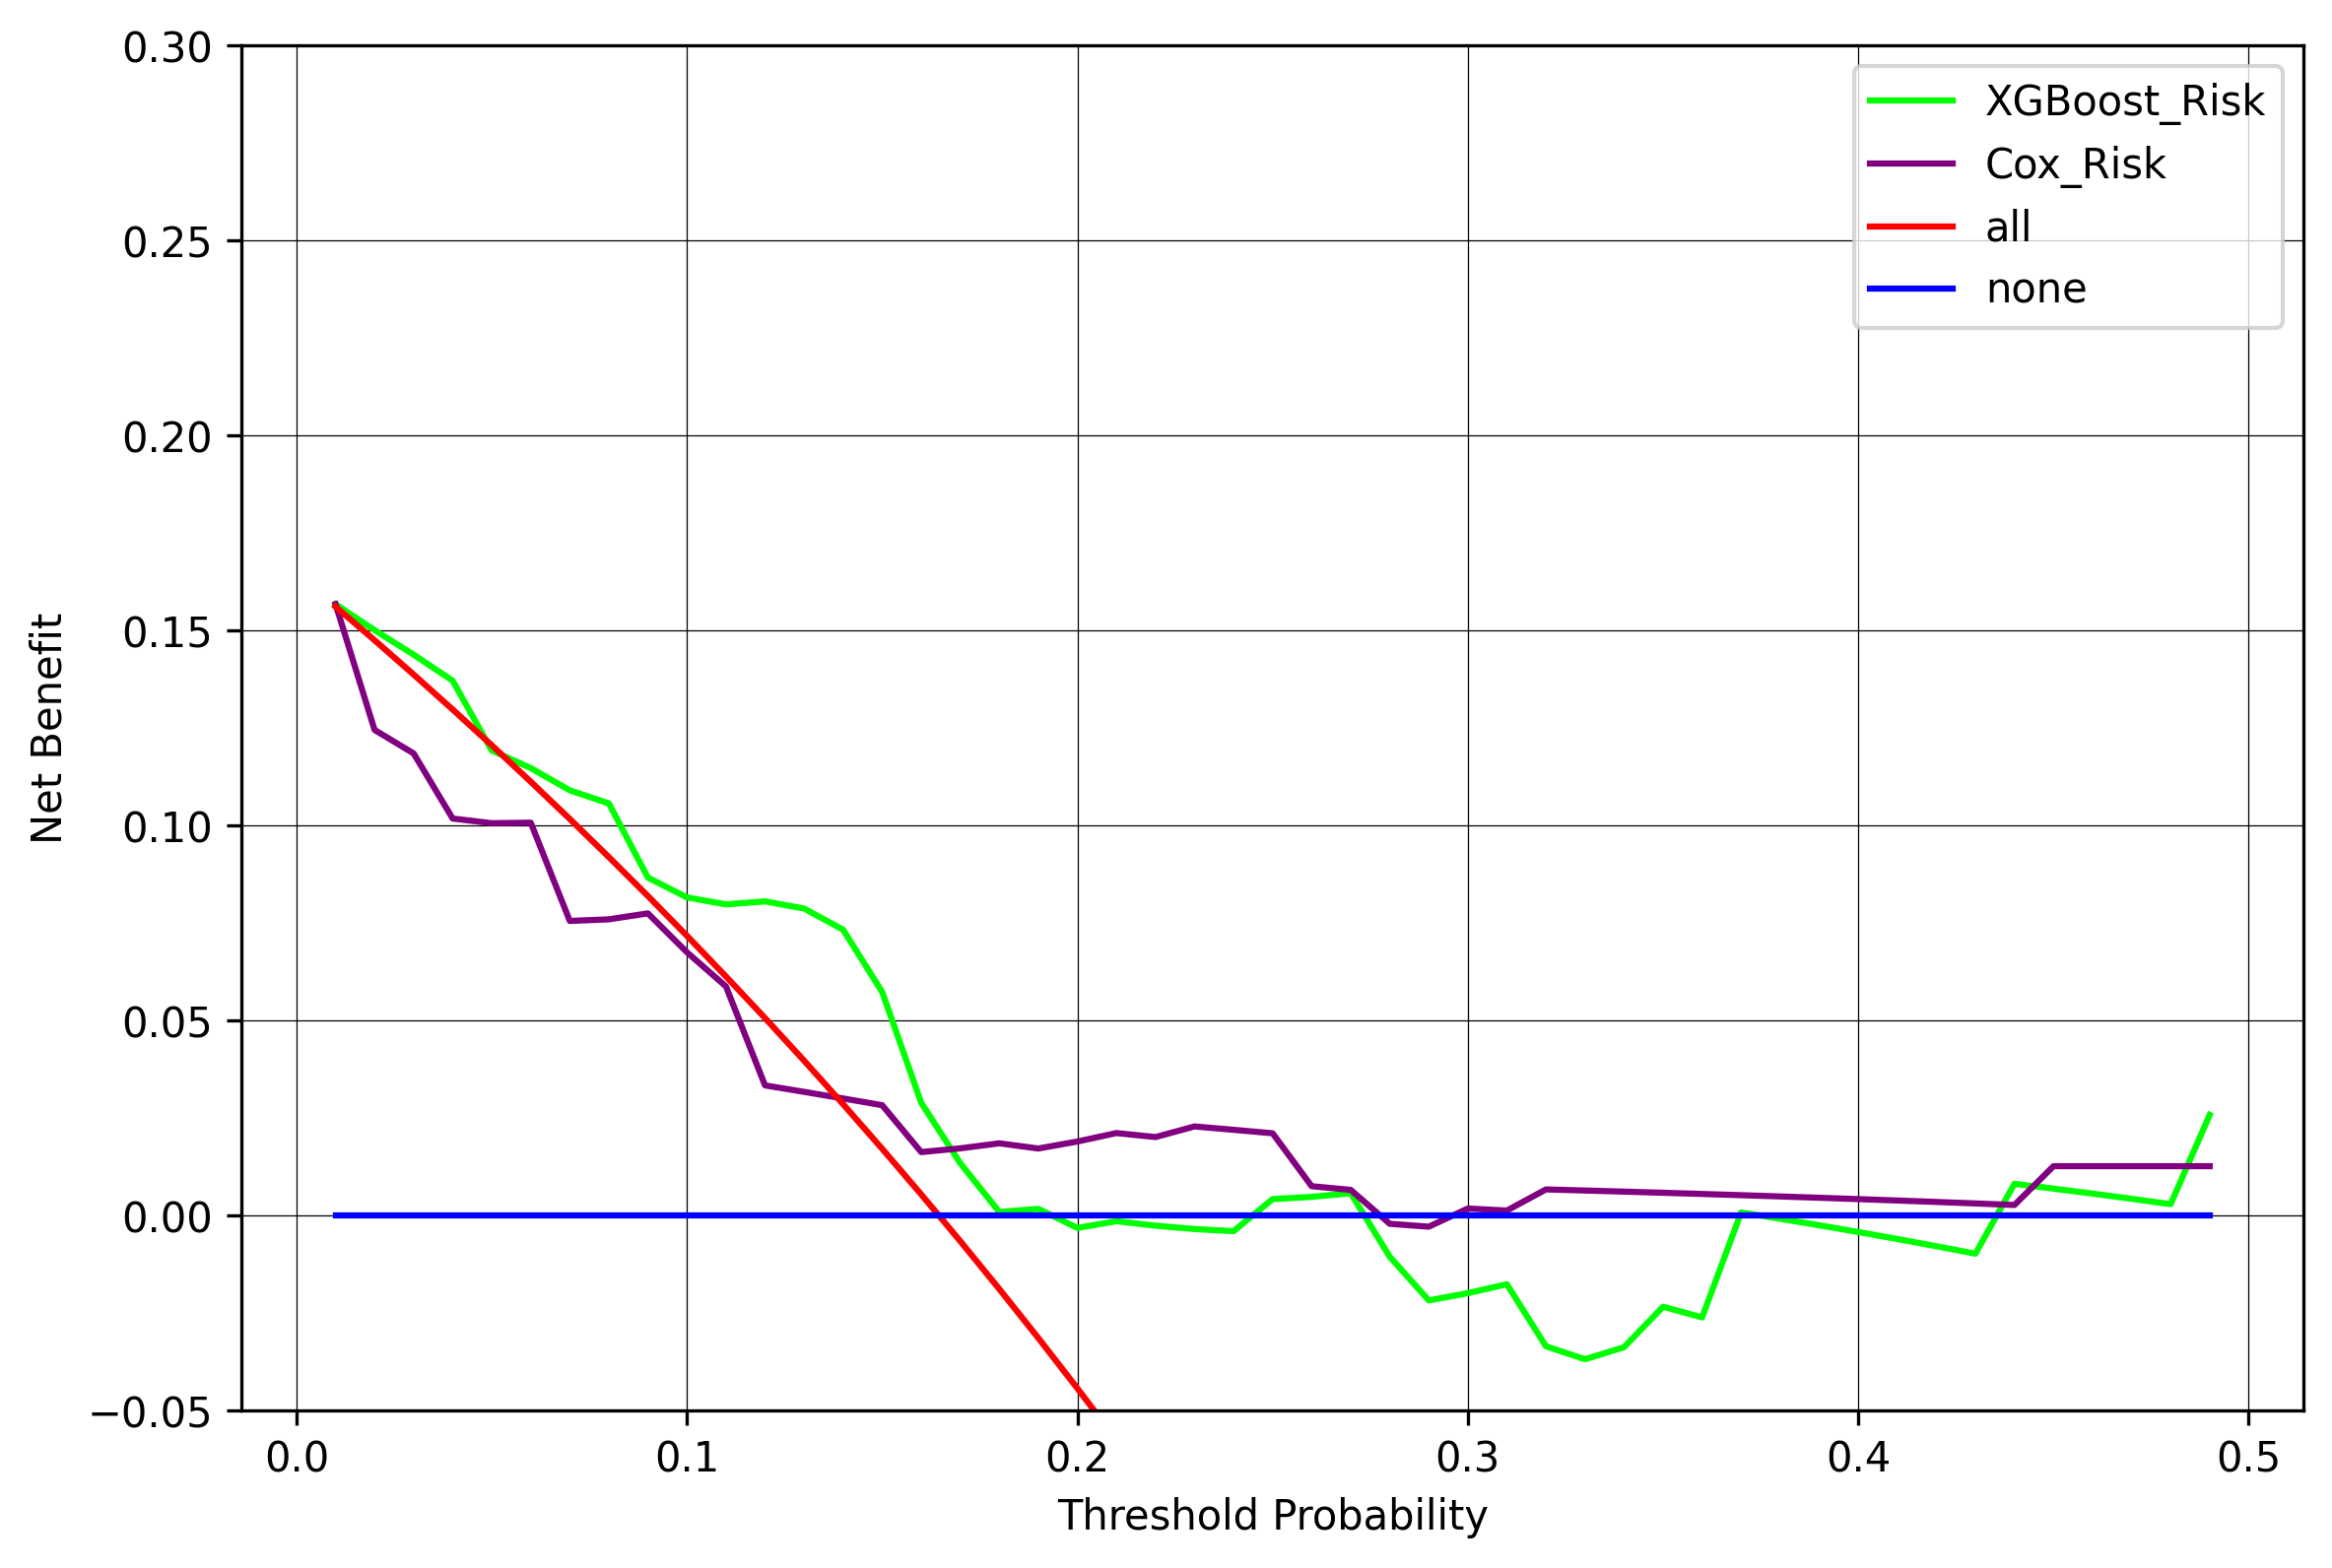

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DCA Plot successfully generated and downloaded.


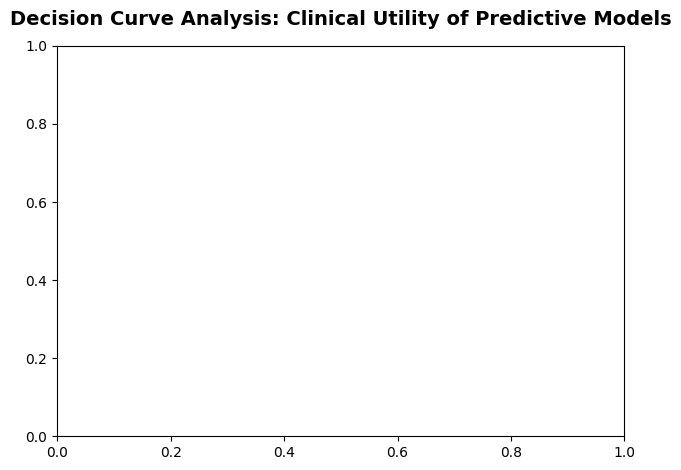

In [20]:
!pip install dcurves -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from dcurves import dca, plot_graphs

print("\n--- PART 2: DECISION CURVE ANALYSIS (DCA) ---")

# 1. Prepare the dataframe for the dcurves library
dca_df = test_df.copy()

# XGBoost and Cox output hazard scores. DCA requires a risk probability between 0 and 1.
# We will use a MinMax Scaler to normalize the hazard scores into a 0-1 risk scale.
scaler = MinMaxScaler()
dca_df['XGBoost_Risk'] = scaler.fit_transform(xgb_predictions.reshape(-1, 1))
dca_df['Cox_Risk'] = scaler.fit_transform(cph_predictions.values.reshape(-1, 1))

# 2. Run the DCA calculation
# It tests thresholds from 0.01 to 0.99
results = dca(
    data=dca_df,
    outcome='EVENT_CONVERTED',
    modelnames=['XGBoost_Risk', 'Cox_Risk'],
    thresholds=np.arange(0.01, 0.50, 0.01) # Clinical thresholds usually peak around 50%
)

# 3. Plot the Decision Curve
plt.figure(figsize=(9, 6), dpi=300)
plot_graphs(
    plot_df=results,
    graph_type='net_benefit',
    y_limits=[-0.05, 0.3]
)

plt.title("Decision Curve Analysis: Clinical Utility of Predictive Models", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Save the high-res image for your paper
plt.savefig('Figure_5_DCA_Plot.png')
from google.colab import files
files.download('Figure_5_DCA_Plot.png')

print("DCA Plot successfully generated and downloaded.")